In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read file
df = pd.read_csv('hotel_bookings.csv')

# create backup from the data.
data_backup = df.copy()


In [2]:
# Quick inspection

print('Dataset shape:', data_backup.shape)
print('Dataset columns:', data_backup.columns.to_list())
print('\nFirst few rows: ')

data_backup.head(10)
data_backup.describe()
data_backup.info()


Dataset shape: (119390, 32)
Dataset columns: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

First few rows: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled     

In [3]:
# check for missing values 

print('\n Missing values per column: ')
missing_data = data_backup.isnull().sum()
missing_data


 Missing values per column: 


hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [4]:
data_backup

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [5]:
# Part 2 

# Handle missing Date.

# first the country 
data_backup['country'] = data_backup['country'].fillna(df['country'].mode()[0])

# second the agent

data_backup['agent'] = data_backup['agent'].fillna(0)

# Third the agent

data_backup['company'] = data_backup['company'].fillna(0)

# Fourth the children

data_backup['children'] = data_backup['children'].fillna(df['children'].mode()[0])


data_backup.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [6]:
data_backup

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0.0,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,0.0,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,0.0,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,0.0,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,0.0,0,Transient,104.40,0,0,Check-Out,2017-09-07


--- Benchmark Metrics (Paying Guests Only) ---
City Hotel Avg ADR:   $106.93
Resort Hotel Avg ADR: $96.77



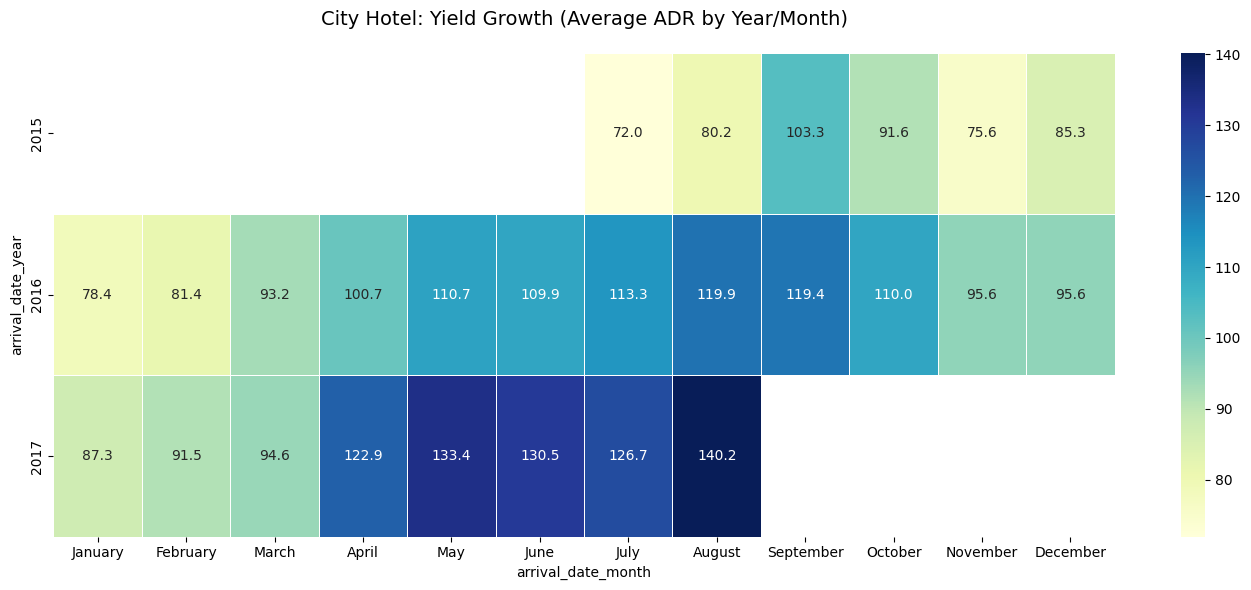

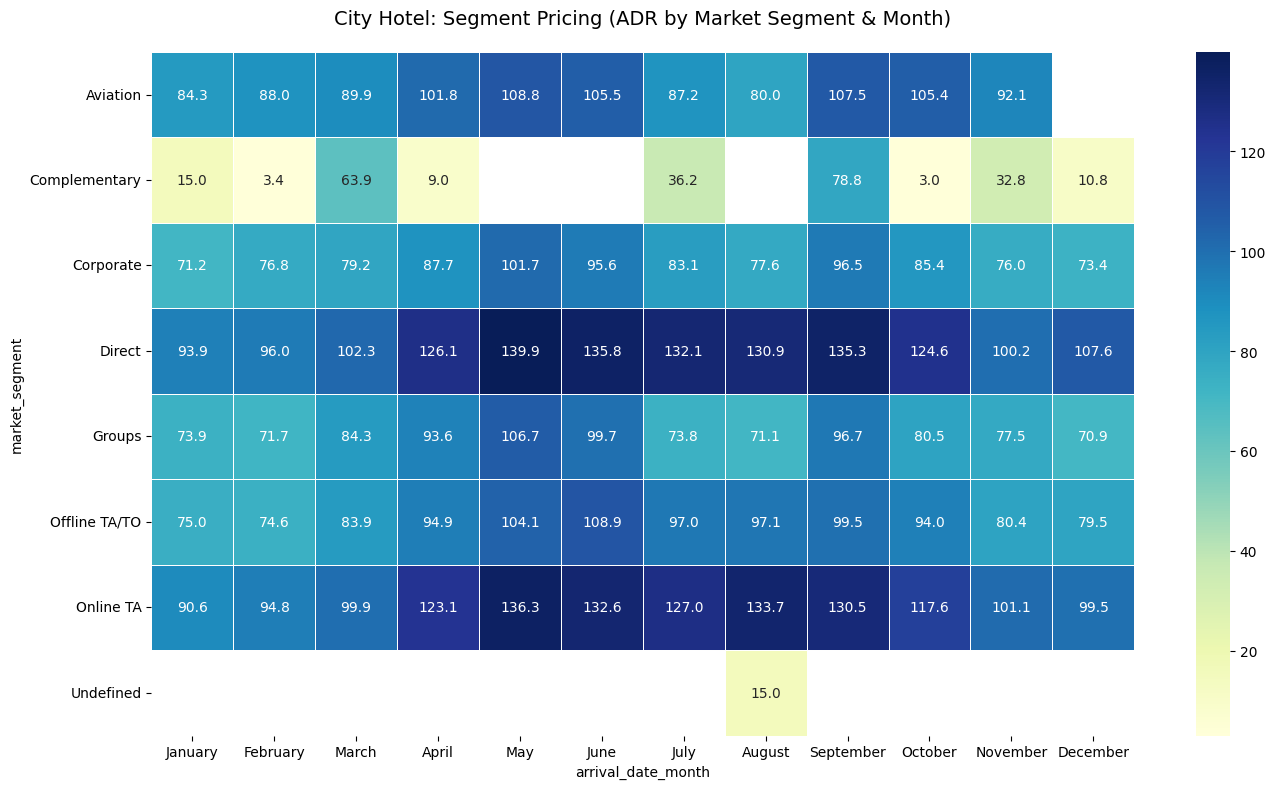

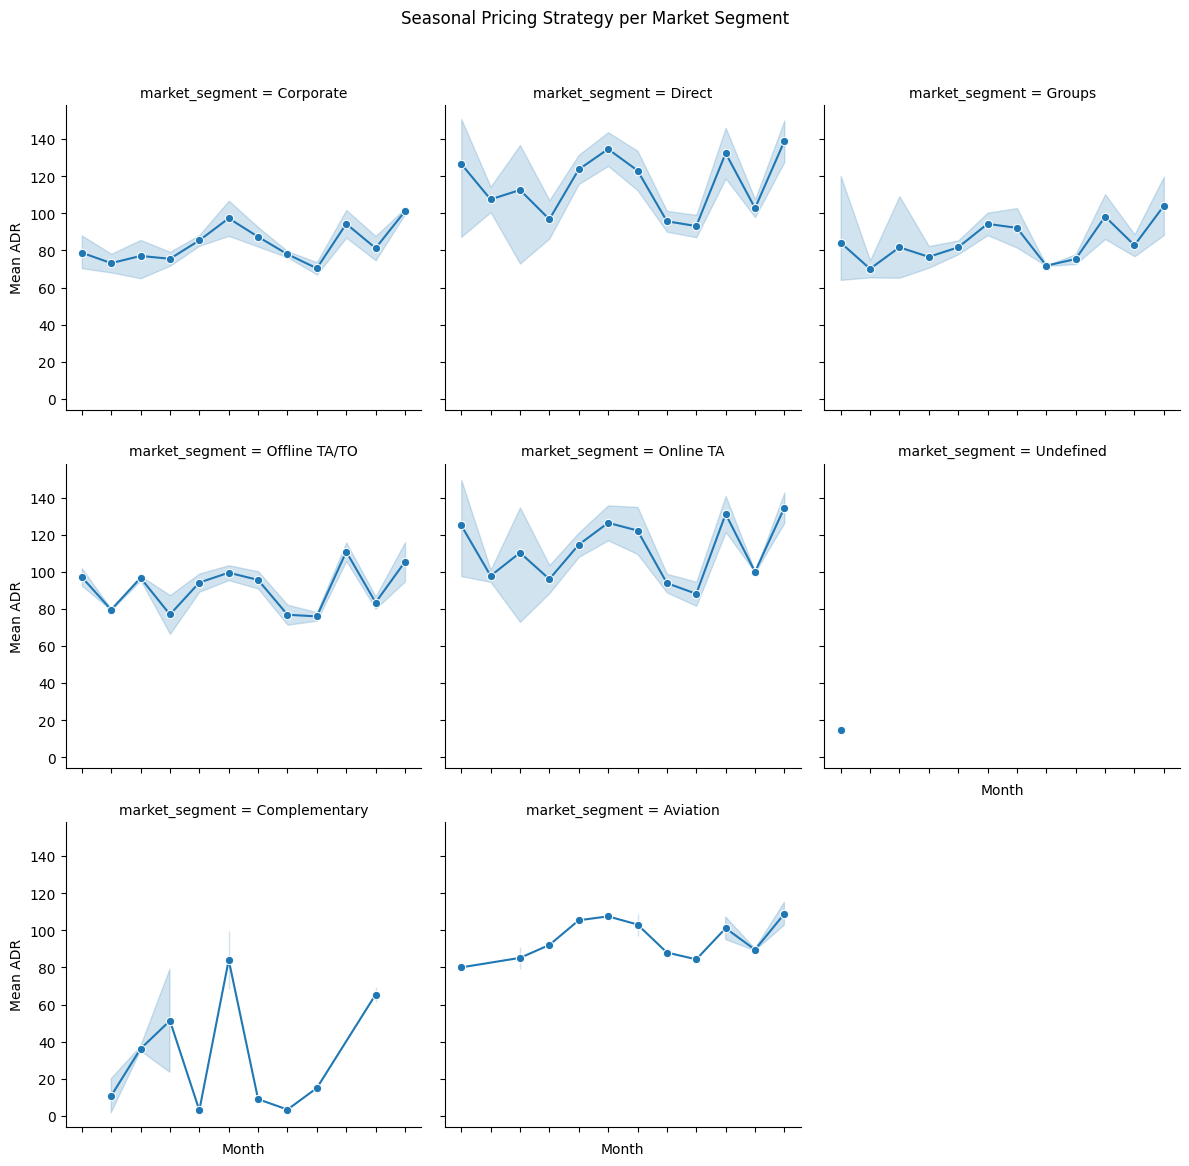

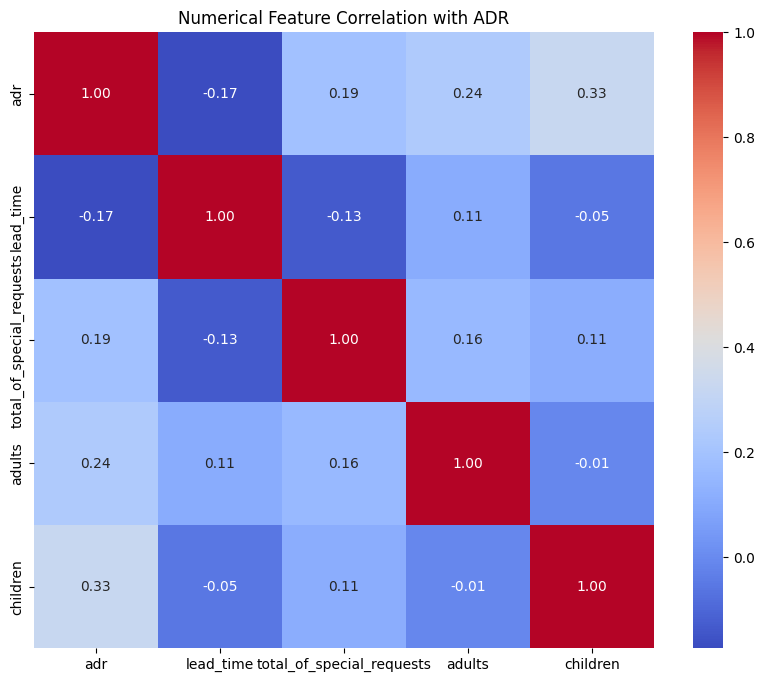

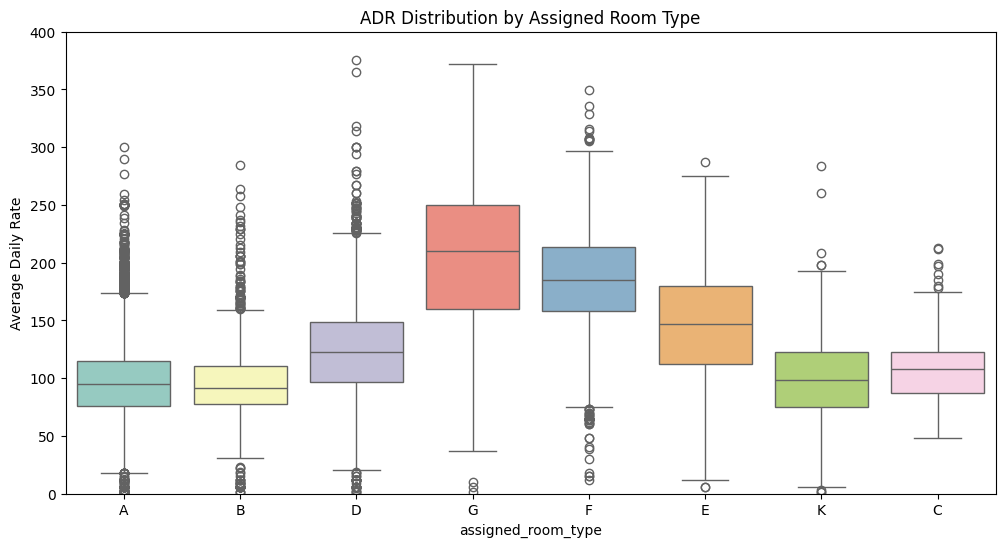

<Figure size 640x480 with 0 Axes>

In [7]:
# =================================================================
# PART 3: EXPLORATORY DATA ANALYSIS (EDA) - CITY HOTEL
# Goal: Analyze pricing drivers to uncover "Revenue DNA"
# =================================================================

# --- 1. Segmentation & Initial Audit ---

# Isolate City Hotel and filter for paying guests (ADR > 0) 
# This ensures our averages reflect actual market revenue
city_hotel = data_backup[(data_backup['hotel'] == 'City Hotel') & (data_backup['adr'] > 0)]

# Benchmark Metrics
resort_hotel = data_backup[(data_backup['hotel'] == 'Resort Hotel') & (data_backup['adr'] > 0)]

city_hotel_Avg_adr = city_hotel['adr'].mean()
resort_hotel_Avg_adr = resort_hotel['adr'].mean()


print(f"--- Benchmark Metrics (Paying Guests Only) ---")
print(f"City Hotel Avg ADR:   ${city_hotel_Avg_adr:.2f}")
print(f"Resort Hotel Avg ADR: ${resort_hotel_Avg_adr:.2f}\n")

# Chronological order for consistent plotting
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]

# --- 2. Heatmap A: Seasonality & Growth (Year vs Month) ---

city_pivot_year = city_hotel.pivot_table(
    index='arrival_date_year', 
    columns='arrival_date_month', 
    values='adr', 
    aggfunc='mean'
).reindex(columns=month_order)

plt.figure(figsize=(14, 6))
sns.heatmap(city_pivot_year, cmap='YlGnBu', annot=True, fmt=".1f", linewidths=.5)
plt.title('City Hotel: Yield Growth (Average ADR by Year/Month)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# --- 3. Heatmap B: Segment Strategy (Market Segment vs Month) ---

segment_pivot = city_hotel.pivot_table(
    index='market_segment', 
    columns=['arrival_date_month'], 
    values='adr', 
    aggfunc='mean'
).reindex(columns=month_order)

plt.figure(figsize=(14, 8))
sns.heatmap(segment_pivot, cmap='YlGnBu', annot=True, fmt=".1f", linewidths=.5)
plt.title('City Hotel: Segment Pricing (ADR by Market Segment & Month)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# --- 4. FaceGrid : Segment Strategy (Market Segment vs Month) ---

segment_adr = (
    city_hotel
    .groupby(['arrival_date_year', 'arrival_date_month', 'market_segment'])['adr']
    .mean()
    .reset_index()
    .sort_values(['arrival_date_year', 'arrival_date_month'])
)

g = sns.FacetGrid(segment_adr, col="market_segment", col_wrap=3, height=4, sharey=True)
g.map(sns.lineplot, "arrival_date_month", "adr", marker="o")
g.set_xticklabels(rotation=45)
g.set_axis_labels("Month", "Mean ADR")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Seasonal Pricing Strategy per Market Segment')
plt.show()

# --- 5. Numerical Correlation: What drives the price? ---
plt.figure(figsize=(10, 8))
# Selecting key numerical features for correlation
corr_features = ['adr', 'lead_time', 'total_of_special_requests', 'adults', 'children']
sns.heatmap(city_hotel[corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Numerical Feature Correlation with ADR')
plt.show()



# --- 6. Room Type Impact: The "Luxury" Factor ---
plt.figure(figsize=(12, 6))
sns.boxplot(x='assigned_room_type', y='adr', data=city_hotel, hue='assigned_room_type', palette='Set3')
plt.title('ADR Distribution by Assigned Room Type')
plt.ylabel('Average Daily Rate')
plt.ylim(0, 400) # Clipping for visibility
plt.show()

plt.tight_layout()


In [8]:
# --- Part 4. Feature Engineering & Encoding ---

# STRATEGY: Outlier Mitigation
# We identified extreme price spikes (e.g., in-room pools) that represent rare transactions.
# Capping ADR at the 99th percentile stabilizes the model against these anomalies.
city_hotel = city_hotel.copy()
q_limit = city_hotel['adr'].quantile(0.99)
city_hotel.loc[:, 'adr'] = city_hotel['adr'].clip(upper=q_limit)
print(f"Operational ADR cap established at: ${q_limit:.2f}")

# STRATEGY: Guest Segmentation
# We transform individual counts into meaningful traveler profiles.
city_hotel['total_guests'] = city_hotel['adults'] + city_hotel['children'] + city_hotel['babies']
city_hotel['is_family'] = ((city_hotel['children'] > 0) | (city_hotel['babies'] > 0)).astype(int)
city_hotel['is_single'] = ((city_hotel['adults'] == 1) & (city_hotel['children'] == 0) & (city_hotel['babies'] == 0)).astype(int)

# STRATEGY: Stay Pattern Analysis
# Identifying 'Weekend Warriors' helps capture city-center business vs. leisure trends.
city_hotel['total_stay_nights'] = city_hotel['stays_in_weekend_nights'] + city_hotel['stays_in_week_nights']
city_hotel['is_weekend_stay'] = (city_hotel['stays_in_weekend_nights'] > 0).astype(int)

# STRATEGY: Demand Seasonality
# Grouping months into Demand Tiers helps the model recognize seasonal pricing power.
def get_season(month):
    if month in ['July', 'August', 'September']: return 'Peak'
    if month in ['May', 'June', 'October']: return 'High'
    if month in ['December', 'January', 'February']: return 'Low'
    return 'Mid'

city_hotel['season'] = city_hotel['arrival_date_month'].apply(get_season)

# STRATEGY: Service Sensitivity
# High request volume often correlates with higher-tier, less price-sensitive guests.
city_hotel['has_special_requests'] = (city_hotel['total_of_special_requests'] > 0).astype(int)

Operational ADR cap established at: $228.32


In [9]:
# --- Part 5: One-Hot Encoding (The Data Translator) ---

# 1. Identify Categorical Features
# We select key business categories that need to be translated into numbers.
categorical_cols = ['market_segment', 'assigned_room_type', 'season', 'customer_type']  

# 2. Perform One-Hot Encoding
# 'drop_first=True' is a strategic choice to remove redundant data. 
# For example, if a guest is NOT 'Single' and NOT 'Group', the model can 
# mathematically infer they are 'Family' without needing a third column.
# This prevents "Multi-collinearity," which keeps the model stable.
city_hotel_final = pd.get_dummies(city_hotel, columns=categorical_cols, drop_first=True)

# 3. Verify the Transformation
# You will notice a significant increase in the number of columns as each 
# category (like 10 room types) expands into its own binary feature.
print(f"Original feature count: {len(city_hotel.columns)}")
print(f"Post-encoding feature count: {len(city_hotel_final.columns)}")



Original feature count: 39
Post-encoding feature count: 55


--- Performance Scorecard ---
Average Error: $7.86 per booking
Model Confidence (R²): 82.70%


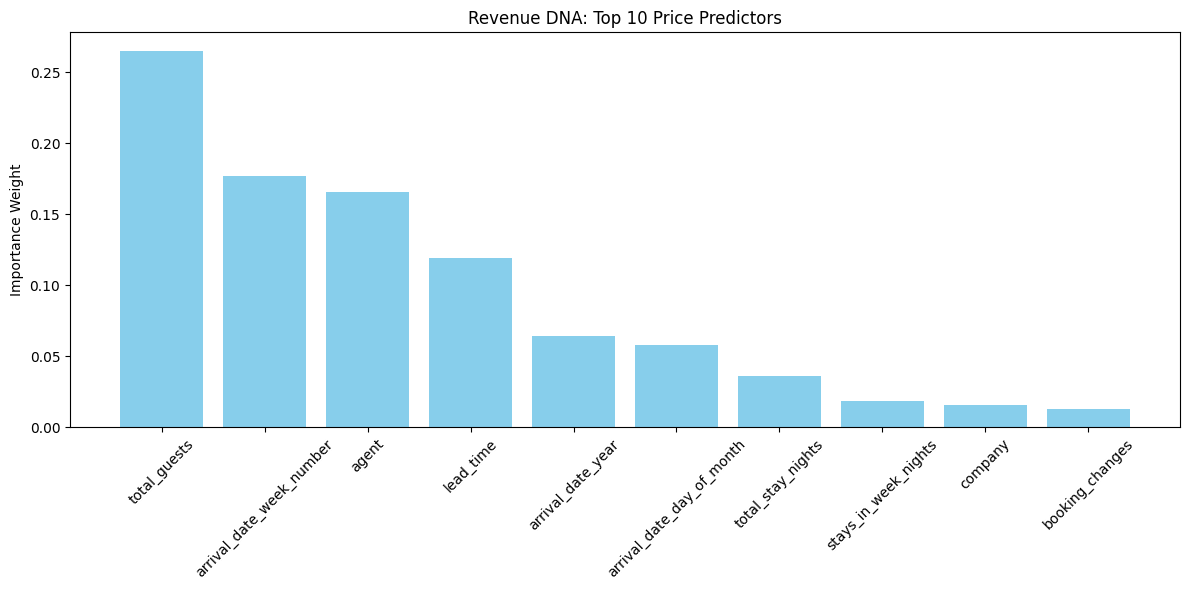

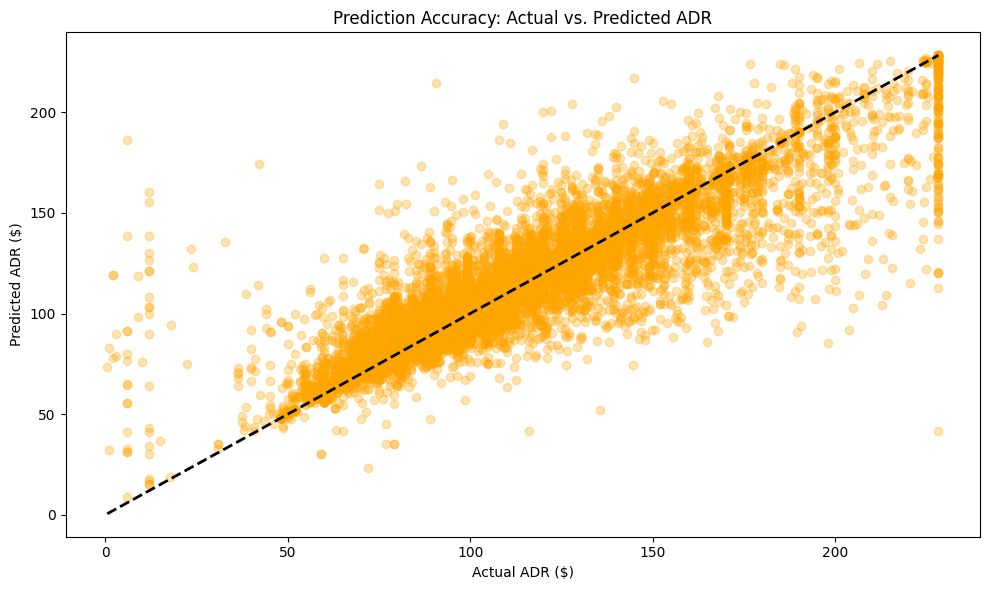

--- Top 5 Most Difficult Bookings to Predict ---
        actual_adr  predicted_adr   abs_error
73335     228.3237      41.683237  186.640463
60176       6.0000     186.262200  180.262200
94510      12.0000     160.186000  148.186000
113865     12.0000     155.247252  143.247252
98782       6.0000     138.723900  132.723900


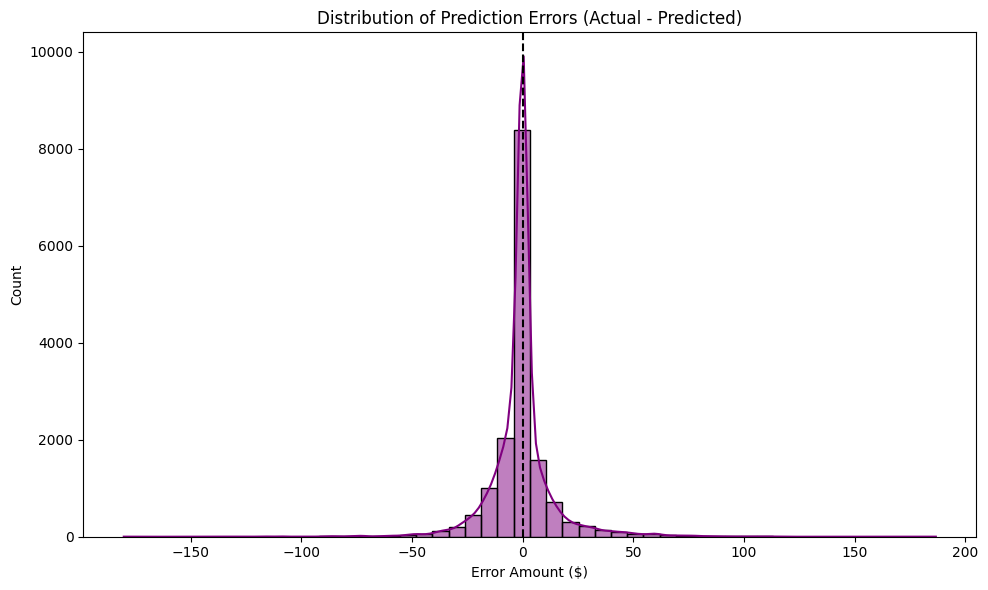

In [10]:
# =================================================================
# PART 6: Training & Auditing the Model
# Goal: Build a Random Forest to predict ADR and uncover pricing drivers
# =================================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DATA SPLIT: Guarding Against Memorization
# Hold out 20% of the data (X_test) to evaluate performance on unseen bookings.
cols_to_drop = ['adr', 'hotel', 'arrival_date_month', 'reservation_status', 'reservation_status_date']
X = city_hotel_final.select_dtypes(include=['number']).drop(columns=cols_to_drop, errors='ignore')
y = city_hotel_final['adr']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. THE FOREST: 100 Trees of Logic
# Random Forest = an ensemble of decision trees.
# Each tree learns a different slice of the data; the forest averages them for stability.
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. PREDICTION & SCORECARD
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Performance Scorecard ---")
print(f"Average Error: ${mae:.2f} per booking")
print(f"Model Confidence (R²): {r2:.2%}")

# 4. REVENUE DNA: Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Revenue DNA: Top 10 Price Predictors")
plt.bar(range(10), importances[indices[:10]], color='skyblue')
plt.xticks(range(10), [X.columns[i] for i in indices[:10]], rotation=45)
plt.ylabel("Importance Weight")
plt.tight_layout()
plt.show()

# Scatter plot: Actual vs Predicted ADR
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual ADR ($)')
plt.ylabel('Predicted ADR ($)')
plt.title('Prediction Accuracy: Actual vs. Predicted ADR')
plt.tight_layout()
plt.show()

# 5. Lead Time Intensity: Normalizing by Stay Length
# Add 1 to denominator to avoid division by zero for 0-night stays.
city_hotel['lead_time_intensity'] = city_hotel['lead_time'] / (city_hotel['total_stay_nights'] + 1)

# 6. Log Transformation: Handling Skewed Lead Times
# Log-scaling helps the model distinguish between short vs. very long booking horizons.
city_hotel['log_lead_time'] = np.log1p(city_hotel['lead_time'])

# 7. Test Results DataFrame
results = X_test.copy()
results['actual_adr'] = y_test
results['predicted_adr'] = y_pred
results['error'] = results['actual_adr'] - results['predicted_adr']
results['abs_error'] = results['error'].abs()

# 8. Top 5 Most Difficult Predictions
worst_predictions = results.sort_values(by='abs_error', ascending=False).head(5)
print("--- Top 5 Most Difficult Bookings to Predict ---")
print(worst_predictions[['actual_adr', 'predicted_adr', 'abs_error']])

# Error Distribution Plot
plt.figure(figsize=(10, 6))
sns.histplot(results['error'], bins=50, kde=True, color='purple')
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Distribution of Prediction Errors (Actual - Predicted)')
plt.xlabel('Error Amount ($)')
plt.tight_layout()
plt.show()